# Generative Model Evaluation
Download models · Generate synthetic tables · Study timestep impact on accuracy

## ⚙️ Configuration — edit here

In [1]:
# ── Hugging Face ──────────────────────────────────────────────────────────────
HF_REPO = "vitaliykinakh/binary-ddpm-tabular"   # <-- set your HF repo

# ── Datasets ─────────────────────────────────────────────────────────────────
# DATASETS = ["adult", "diabetes", "heloc", "housing", "sick", "travel"]
DATASETS = ["adult", "heloc"]   # <-- for testing, use just one dataset

# ── Directories ───────────────────────────────────────────────────────────────
MODELS_DIR    = "./models"
OUTPUTS_DIR   = "./outputs"
EVAL_CONFIGS_DIR = "./eval_configs"
DATA_DIR      = "./data"

# ── Default sampling parameters ───────────────────────────────────────────────
DEFAULT_SAMPLE_PARAMS = dict(
    n_timesteps    = 5,
    batch_size     = 256,
    guidance_scale = 5.0,
    use_ema        = True,
)

# ── Timestep study ────────────────────────────────────────────────────────────
TIMESTEPS_TO_STUDY = [2, 5, 10, 20, 50, 100]
SCHEDULE_TO_STUDY  = ["linear", "quad", "sigmoid", "threshold"]
N_RUNS_PER_STEP    = 5   # synthetic datasets generated per timestep value


## 📦 Imports

In [2]:
import os, copy, yaml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from huggingface_hub import hf_hub_download

from sample   import sample
from evaluate import evaluate


c:\Users\Sinbad\anaconda3\envs\binary-diffusion-tabular\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ⬇️ Download models from Hugging Face

In [3]:
def download_models(datasets, repo, models_dir):
    """Download model-final.pt and transformation.joblib for each dataset."""
    paths = {}
    for ds in datasets:
        dst = Path(models_dir) / ds
        dst.mkdir(parents=True, exist_ok=True)

        model_path = dst / "model-final.pt"
        transform_path = dst / "transformation.joblib"

        if not model_path.exists():
            print(f"[{ds}] Downloading model …")
            hf_hub_download(repo_id=repo,
                            filename=f"{ds}/model-final.pt",
                            local_dir=models_dir)
        if not transform_path.exists():
            print(f"[{ds}] Downloading transformation …")
            hf_hub_download(repo_id=repo,
                            filename=f"{ds}/transformation.joblib",
                            local_dir=models_dir)

        paths[ds] = dict(ckpt=str(model_path), ckpt_transformation=str(transform_path))
        print(f"[{ds}] ✓ ready")
    return paths

model_paths = download_models(DATASETS, HF_REPO, MODELS_DIR)


[adult] ✓ ready
[heloc] ✓ ready


## 🛠️ Helpers

In [4]:
def get_n_samples(dataset_name):
    """Count rows in the training CSV (excluding header) to match n_samples."""
    train_csv = Path(DATA_DIR) / f"{dataset_name}_train.csv"
    return sum(1 for _ in open(train_csv)) - 1   # subtract header


def get_target_column(dataset_name):
    """Read target_column from the eval config (data.target_column)."""
    cfg_path = Path(EVAL_CONFIGS_DIR) / f"{dataset_name}.yml"
    cfg = yaml.safe_load(open(cfg_path))
    return cfg["data"]["target_column"]


def build_eval_cfg(dataset_name, synthetic_paths):
    """Load the eval config and patch path_synthetic_trains."""
    cfg_path = Path(EVAL_CONFIGS_DIR) / f"{dataset_name}.yml"
    cfg = yaml.safe_load(open(cfg_path))
    cfg["path_synthetic_trains"] = [str(p) for p in synthetic_paths]
    # keep path_test pointing at the right test file
    cfg["path_test"] = str(Path(DATA_DIR) / f"{dataset_name}_test.csv")
    return cfg


## 🔄 Baseline generation
Generate **N_RUNS_PER_STEP** synthetic tables per dataset using the default timestep.

In [5]:
baseline_csv = {}   # dataset → list of CSV paths

for ds in DATASETS:
    n_samples = get_n_samples(ds)
    out_dir   = Path(OUTPUTS_DIR) / ds / "baseline"
    out_dir.mkdir(parents=True, exist_ok=True)
    csvs = []

    for run in range(N_RUNS_PER_STEP):
        out_path = out_dir / f"samples_{run}.csv"
        if out_path.exists():
            print(f"[{ds}] run {run} already exists, skipping")
        else:
            print(f"[{ds}] generating run {run} …")
            sample(
                ckpt                 = model_paths[ds]["ckpt"],
                ckpt_transformation  = model_paths[ds]["ckpt_transformation"],
                out                  = str(out_dir / f"samples_{run}.csv"),   # sample() adds .csv
                n_samples            = n_samples,
                target_column_name   = get_target_column(ds),
                **DEFAULT_SAMPLE_PARAMS,
            )
        csvs.append(out_path)

    baseline_csv[ds] = csvs
    print(f"[{ds}] ✓  {len(csvs)} files ready\n")


[adult] run 0 already exists, skipping
[adult] run 1 already exists, skipping
[adult] run 2 already exists, skipping
[adult] run 3 already exists, skipping
[adult] run 4 already exists, skipping
[adult] ✓  5 files ready

[heloc] run 0 already exists, skipping
[heloc] run 1 already exists, skipping
[heloc] run 2 already exists, skipping
[heloc] run 3 already exists, skipping
[heloc] run 4 already exists, skipping
[heloc] ✓  5 files ready



## 📊 Baseline evaluation

In [6]:
baseline_results = {}

for ds in DATASETS:
    cfg = build_eval_cfg(ds, baseline_csv[ds])
    res = evaluate(cfg)
    baseline_results[ds] = res
    print(f"[{ds}]  metric={res['metric']}")
    for model, scores in res["models"].items():
        print(f"  {model}: {scores['mean']:.4f} ± {scores['std']:.4f}")
    print()


  [run 1/5] outputs\adult\baseline\samples_0.csv
  [run 2/5] outputs\adult\baseline\samples_1.csv
  [run 3/5] outputs\adult\baseline\samples_2.csv
  [run 4/5] outputs\adult\baseline\samples_3.csv
  [run 5/5] outputs\adult\baseline\samples_4.csv

Dataset: ADULT | Task: classification | Metric: ACCURACY
Model           Mean         Std  All scores
------------------------------------------------------------
LR            0.8478      0.0021  [0.8510  0.8447  0.8464  0.8487  0.8478]
DT            0.8368      0.0052  [0.8438  0.8409  0.8369  0.8291  0.8334]
RF            0.8334      0.0029  [0.8363  0.8342  0.8357  0.8282  0.8325]

[adult]  metric=accuracy
  LR: 0.8478 ± 0.0021
  DT: 0.8368 ± 0.0052
  RF: 0.8334 ± 0.0029

  [run 1/5] outputs\heloc\baseline\samples_0.csv
  [run 2/5] outputs\heloc\baseline\samples_1.csv
  [run 3/5] outputs\heloc\baseline\samples_2.csv
  [run 4/5] outputs\heloc\baseline\samples_3.csv
  [run 5/5] outputs\heloc\baseline\samples_4.csv

Dataset: HELOC | Task: clas

## 🔬 Timestep study
For each dataset and each timestep value, generate `N_RUNS_PER_STEP` synthetic tables.

In [7]:
# ── helpers ───────────────────────────────────────────────────────────────────
def schedule_sample_kwargs(schedule_name: str) -> dict:
    """
    Translate a schedule label into the kwargs accepted by `sample()`.
    'threshold' is not a schedule function: it uses a fixed 0.5 threshold
    and falls back to the default (linear) schedule.
    """
    if schedule_name == "threshold":
        return {"threshold": 0.5}          # no `schedule` kwarg → default "linear"
    return {"schedule": schedule_name}


# study_csv[ds][T][schedule] → list of Path
study_csv = {ds: {T: {} for T in TIMESTEPS_TO_STUDY} for ds in DATASETS}

for ds in DATASETS:
    n_samples = get_n_samples(ds)
    params    = {**DEFAULT_SAMPLE_PARAMS}

    for T in TIMESTEPS_TO_STUDY:
        for sched in SCHEDULE_TO_STUDY:
            out_dir = Path(OUTPUTS_DIR) / ds / f"T{T}" / sched
            out_dir.mkdir(parents=True, exist_ok=True)

            csvs = []
            for run in range(N_RUNS_PER_STEP):
                out_path = out_dir / f"samples_{run}.csv"

                if out_path.exists():
                    print(f"[{ds}|T={T}|{sched}] run {run} already exists – skipping")
                else:
                    print(f"[{ds}|T={T}|{sched}] generating run {run} …")
                    sample(
                        ckpt                = model_paths[ds]["ckpt"],
                        ckpt_transformation = model_paths[ds]["ckpt_transformation"],
                        out                 = str(out_path),
                        n_samples           = n_samples,
                        n_timesteps         = T,
                        batch_size          = params["batch_size"],
                        guidance_scale      = params["guidance_scale"],
                        use_ema             = params["use_ema"],
                        target_column_name  = get_target_column(ds),
                        **schedule_sample_kwargs(sched),   # schedule OR threshold
                    )

                csvs.append(out_path)

            study_csv[ds][T][sched] = csvs

print("Generation complete.")

c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_data = torch.load(ckpt

[adult|T=2|linear] run 0 already exists – skipping
[adult|T=2|linear] run 1 already exists – skipping
[adult|T=2|linear] run 2 already exists – skipping
[adult|T=2|linear] run 3 already exists – skipping
[adult|T=2|linear] run 4 already exists – skipping
[adult|T=2|quad] run 0 already exists – skipping
[adult|T=2|quad] run 1 already exists – skipping
[adult|T=2|quad] run 2 already exists – skipping
[adult|T=2|quad] run 3 already exists – skipping
[adult|T=2|quad] run 4 already exists – skipping
[adult|T=2|sigmoid] run 0 already exists – skipping
[adult|T=2|sigmoid] run 1 already exists – skipping
[adult|T=2|sigmoid] run 2 already exists – skipping
[adult|T=2|sigmoid] run 3 already exists – skipping
[adult|T=2|sigmoid] run 4 already exists – skipping
[adult|T=2|threshold] run 0 already exists – skipping
[adult|T=2|threshold] run 1 already exists – skipping
[adult|T=2|threshold] run 2 already exists – skipping
[adult|T=2|threshold] run 3 already exists – skipping
[adult|T=2|threshold] ru

8448it [00:02, 3635.15it/s]                          
c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to th

outputs\heloc\T2\linear\samples_0.csv
Saved 8367 samples to outputs\heloc\T2\linear\samples_0.csv
[heloc|T=2|linear] generating run 1 …


8448it [00:02, 3796.06it/s]                          
c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to th

...

outputs\heloc\T100\threshold\samples_2.csv
Saved 8367 samples to outputs\heloc\T100\threshold\samples_2.csv
[heloc|T=100|threshold] generating run 3 …


8448it [00:16, 511.31it/s]                          
c:\Users\Sinbad\Documents\GitHub\computational_imaging\code\binary-diffusion-tabular\sample.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to thi

outputs\heloc\T100\threshold\samples_3.csv
Saved 8367 samples to outputs\heloc\T100\threshold\samples_3.csv
[heloc|T=100|threshold] generating run 4 …


8448it [00:16, 509.29it/s]                          

outputs\heloc\T100\threshold\samples_4.csv
Saved 8367 samples to outputs\heloc\T100\threshold\samples_4.csv
Generation complete.


## 📈 Evaluate & plot

In [8]:
# study_results[ds][T][schedule] → evaluate() output
study_results = {ds: {T: {} for T in TIMESTEPS_TO_STUDY} for ds in DATASETS}

for ds in DATASETS:
    for T in TIMESTEPS_TO_STUDY:
        for sched in SCHEDULE_TO_STUDY:
            print(f"[{ds}|T={T}|{sched}] evaluating …")
            cfg = build_eval_cfg(ds, study_csv[ds][T][sched])
            study_results[ds][T][sched] = evaluate(cfg)

print("Evaluation complete.")

[adult|T=2|linear] evaluating …
  [run 1/5] outputs\adult\T2\linear\samples_0.csv
  [run 2/5] outputs\adult\T2\linear\samples_1.csv
  [run 3/5] outputs\adult\T2\linear\samples_2.csv
  [run 4/5] outputs\adult\T2\linear\samples_3.csv
  [run 5/5] outputs\adult\T2\linear\samples_4.csv

Dataset: ADULT | Task: classification | Metric: ACCURACY
Model           Mean         Std  All scores
------------------------------------------------------------
LR            0.8138      0.0039  [0.8093  0.8113  0.8116  0.8177  0.8193]
DT            0.8098      0.0018  [0.8119  0.8071  0.8116  0.8090  0.8094]
RF            0.8045      0.0020  [0.8057  0.8021  0.8034  0.8076  0.8034]

[adult|T=2|quad] evaluating …
  [run 1/5] outputs\adult\T2\quad\samples_0.csv
  [run 2/5] outputs\adult\T2\quad\samples_1.csv
  [run 3/5] outputs\adult\T2\quad\samples_2.csv
  [run 4/5] outputs\adult\T2\quad\samples_3.csv
  [run 5/5] outputs\adult\T2\quad\samples_4.csv

Dataset: ADULT | Task: classification | Metric: ACCURACY


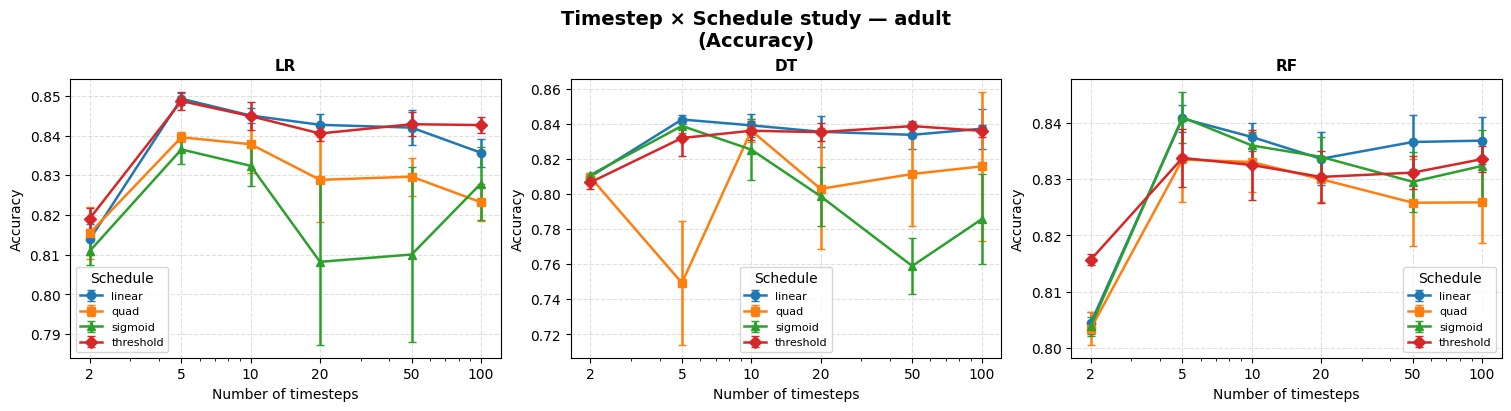

Figure saved → timestep_schedule_study_adult.png


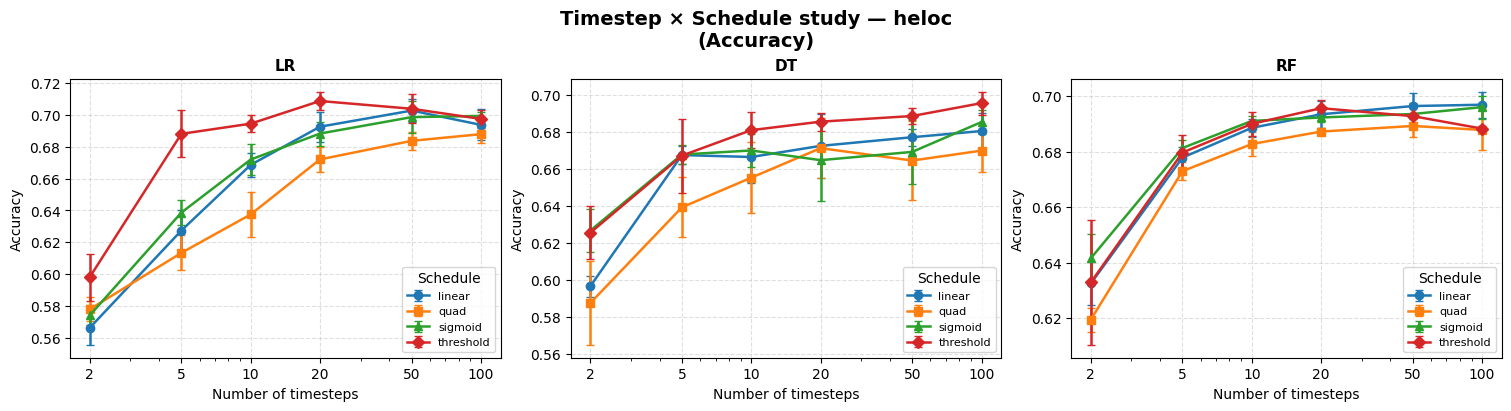

Figure saved → timestep_schedule_study_heloc.png


In [9]:
# One figure per dataset.
# Each figure: one subplot per downstream model, x = timesteps, one line per schedule.

def plot_timestep_schedule_study(datasets, study_results, timesteps, schedules):
    # colour-code schedules, marker-code downstream models
    sched_colors = plt.cm.tab10.colors
    model_markers = ["o", "s", "^", "D", "v", "P", "*"]

    for ds in datasets:
        res = study_results[ds]

        # collect downstream model names from the first (T, sched) cell
        first_cell = res[timesteps[0]][schedules[0]]
        model_names = list(first_cell["models"].keys())
        metric      = first_cell["metric"]

        n_models = len(model_names)
        ncols    = min(3, n_models)
        nrows    = -(-n_models // ncols)

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(5 * ncols, 4 * nrows),
            sharey=False,
            constrained_layout=True,
        )
        axes = np.array(axes).flatten()   # works for 1-D and 2-D grids

        for ax, model in zip(axes, model_names):
            for s_idx, sched in enumerate(schedules):
                means = [res[T][sched]["models"][model]["mean"] for T in timesteps]
                stds  = [res[T][sched]["models"][model]["std"]  for T in timesteps]
                ax.errorbar(
                    timesteps, means, yerr=stds,
                    label=sched,
                    color=sched_colors[s_idx % len(sched_colors)],
                    marker=model_markers[s_idx % len(model_markers)],
                    capsize=3,
                    linewidth=1.8,
                )
            ax.set_title(model, fontsize=11, fontweight="bold")
            ax.set_xlabel("Number of timesteps")
            ax.set_ylabel(metric.capitalize())
            ax.set_xscale("log")
            ax.set_xticks(timesteps)
            ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
            ax.legend(title="Schedule", fontsize=8)
            ax.grid(True, linestyle="--", alpha=0.4)

        # hide unused subplot slots
        for ax in axes[n_models:]:
            ax.set_visible(False)

        fig.suptitle(
            f"Timestep × Schedule study — {ds}\n({metric.capitalize()})",
            fontsize=14, fontweight="bold",
        )

        fname = f"timestep_schedule_study_{ds}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Figure saved → {fname}")


plot_timestep_schedule_study(DATASETS, study_results, TIMESTEPS_TO_STUDY, SCHEDULE_TO_STUDY)

## 🗂️ Summary table

In [13]:
rows = []
for ds in DATASETS:
    for T in TIMESTEPS_TO_STUDY:
        res = study_results[ds][T]
        for model, scores in res["models"].items():
            rows.append(dict(
                dataset   = ds,
                timesteps = T,
                model     = model,
                mean      = round(scores["mean"], 4),
                std       = round(scores["std"],  4),
            ))

summary = pd.DataFrame(rows)
summary.to_csv("timestep_study_results.csv", index=False)
summary


,dataset,timesteps,model,mean,std
0,adult,2,LR,0.8203,0.0028
1,adult,2,DT,0.8084,0.0020
2,adult,2,RF,0.8169,0.0012
3,adult,5,LR,0.8499,0.0022
4,adult,5,DT,0.8389,0.0085
5,adult,5,RF,0.8346,0.0049
6,adult,10,LR,0.8421,0.0037
7,adult,10,DT,0.8363,0.0069
8,adult,10,RF,0.8315,0.0041
